Getting the data into Data Frame

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df= pd.read_csv("C:\\Users\\sahir\\Desktop\\Churn Analysis Project\\Customer_Data.csv")

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [12]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Checking the no of customers who churned from the Data

In [20]:
Churned_Customers = (df['Churn']=='Yes').sum()
print(Churned_Customers)

1869


In [21]:
total_customers = len(df)
total_customers

7043

In [29]:
Churned_Percentage = (Churned_Customers * 100.0) / total_customers
print("Percentage of Customer who Churned:  "f"{round(Churned_Percentage,1)}%")


Percentage of Customer who Churned:  26.5%


In [51]:
Global_ARPU = df['MonthlyCharges'].mean() 
print(f"Global Benchmark ARPU: ${round(Global_ARPU, 2)}")

Global Benchmark ARPU: $64.76


In [52]:
Active_ARPU = df[df['Churn'] == 'No']['MonthlyCharges'].mean()
print(f"Active Customer ARPU: ${round(Active_ARPU, 2)}")

Active Customer ARPU: $61.27


In [53]:
Churned_ARPU = df[df['Churn'] == 'Yes']['MonthlyCharges'].mean()
print(f"Churned Customer ARPU: ${round(Churned_ARPU, 2)}")

Churned Customer ARPU: $74.44


In [54]:
Total_Revenue_Leaking = df[df['Churn'] == 'Yes']['MonthlyCharges'].sum()
print(f"Total Monthly Revenue Leaking: ${round(Total_Revenue_Leaking, 2)}")

Total Monthly Revenue Leaking: $139130.85


In [55]:
Contract_Churn_Rate = df.groupby('Contract')['Churn'].value_counts(normalize=True) * 100
print("Contract Churn Percentages:\n", Contract_Churn_Rate)

Contract Churn Percentages:
 Contract        Churn
Month-to-month  No       57.290323
                Yes      42.709677
One year        No       88.730482
                Yes      11.269518
Two year        No       97.168142
                Yes       2.831858
Name: proportion, dtype: float64


In [56]:
Internet_Churn_Rate = df.groupby('InternetService')['Churn'].value_counts(normalize=True) * 100
print("\nInternet Service Churn Percentages:\n", Internet_Churn_Rate)


Internet Service Churn Percentages:
 InternetService  Churn
DSL              No       81.040892
                 Yes      18.959108
Fiber optic      No       58.107235
                 Yes      41.892765
No               No       92.595020
                 Yes       7.404980
Name: proportion, dtype: float64


In [57]:
Payment_Churn_Rate = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True) * 100
print("\nPayment Method Churn Percentages:\n", Payment_Churn_Rate)


Payment Method Churn Percentages:
 PaymentMethod              Churn
Bank transfer (automatic)  No       83.290155
                           Yes      16.709845
Credit card (automatic)    No       84.756899
                           Yes      15.243101
Electronic check           No       54.714588
                           Yes      45.285412
Mailed check               No       80.893300
                           Yes      19.106700
Name: proportion, dtype: float64


In [58]:
#Adding normalize=True tells Pandas to calculate proportions instead of counts

In [71]:
print("--- Tenure (Months on Network) Summary ---")
tenure_stats = df.groupby('Churn')['tenure'].agg(['mean', 'median', 'min', 'max'])
print(tenure_stats)

--- Tenure (Months on Network) Summary ---
            mean  median  min  max
Churn                             
No     37.569965    38.0    0   72
Yes    17.979133    10.0    1   72


In [72]:
print("\n--- Monthly Charges Summary ---")
charges_stats = df.groupby('Churn')['MonthlyCharges'].agg(['mean', 'median'])
print(charges_stats)


--- Monthly Charges Summary ---
            mean  median
Churn                   
No     61.265124  64.425
Yes    74.441332  79.650


In [74]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("\n--- Total Lifetime Charges Summary ---")
total_charges_stats = df.groupby('Churn')['TotalCharges'].agg(['mean', 'median'])
print(total_charges_stats)



--- Total Lifetime Charges Summary ---
              mean   median
Churn                      
No     2555.344141  1683.60
Yes    1531.796094   703.55


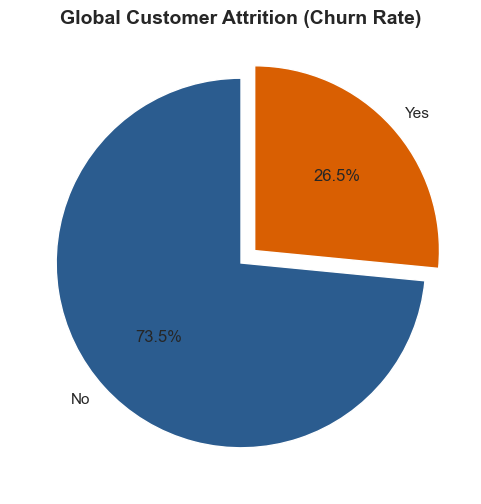

In [75]:

sns.set_theme(style="whitegrid")

# Create canvas
plt.figure(figsize=(6, 6))

# Count occurrences
churn_counts = df['Churn'].value_counts()

# Plot Pie Chart
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', 
        colors=['#2b5c8f', '#d95f02'], startangle=90, explode=(0, 0.1))

plt.title('Global Customer Attrition (Churn Rate)', fontsize=14, fontweight='bold')
plt.show()

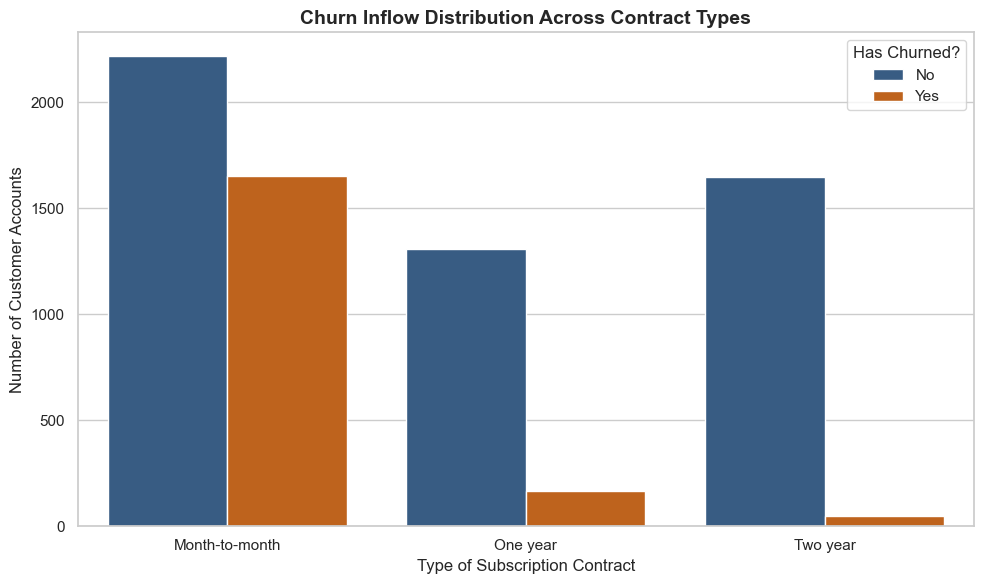

In [76]:
plt.figure(figsize=(10, 6))

# Plot Countplot segmented by Churn status
sns.countplot(x='Contract', hue='Churn', data=df, palette=['#2b5c8f', '#d95f02'])

# Add clear business context labels
plt.title('Churn Inflow Distribution Across Contract Types', fontsize=14, fontweight='bold')
plt.xlabel('Type of Subscription Contract', fontsize=12)
plt.ylabel('Number of Customer Accounts', fontsize=12)
plt.legend(title='Has Churned?')

plt.tight_layout()
plt.show()

C:\Users\sahir\AppData\Local\Temp\ipykernel_5836\378313311.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette=['#2b5c8f', '#d95f02'])


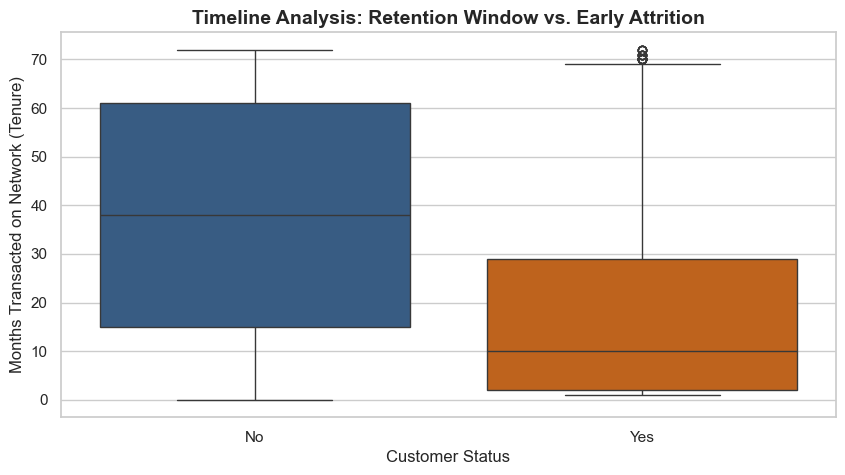

In [77]:
plt.figure(figsize=(10, 5))

# Plot Boxplot contrasting tenure timelines
sns.boxplot(x='Churn', y='tenure', data=df, palette=['#2b5c8f', '#d95f02'])

plt.title('Timeline Analysis: Retention Window vs. Early Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Customer Status', fontsize=12)
plt.ylabel('Months Transacted on Network (Tenure)', fontsize=12)

plt.show()